### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Preprocessed Data Loading

In [2]:
X = pd.read_csv('X.csv')
y = pd.read_csv('y.csv')

In [3]:
print(X.shape)
print(y.shape)

(352555, 5)
(352555, 1)


In [4]:
X.head()

,CallHour,NotifyLowerTierDescription,Year,Month,Day
0,-2.01315,-1.547752,-1.618971,-1.626487,-1.666247
1,-2.01315,-1.547752,-1.618971,-1.626487,-1.552916
2,-2.01315,-1.547752,-1.618971,-1.626487,-1.326255
3,-2.01315,-1.547752,-1.618971,-1.626487,-0.079619
4,-2.01315,-1.547752,-1.618971,-1.626487,0.260373


In [5]:
y.head()

,count
0,1
1,1
2,1
3,1
4,1


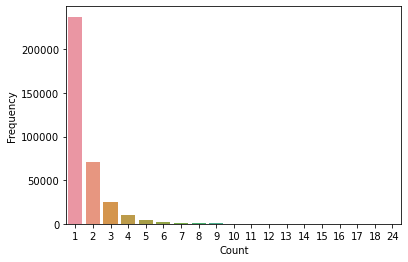

1     237374
2      70670
3      24416
4      10130
5       4843
6       2548
7       1274
8        632
9        356
10       156
11        75
12        40
13        24
14         8
17         2
15         2
18         2
16         2
24         1
Name: count, dtype: int64

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=y, x='count')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

y['count'].value_counts()

### Data Splitting

In [7]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the resulting training and testing sets
print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:', X_test.shape, y_test.shape)

Training set shape: (282044, 5) (282044, 1)
Testing set shape: (70511, 5) (70511, 1)


### Model Training

#### Sequential Neural Network

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the model architecture
model11 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(5,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

# Compile the model
model11.compile(optimizer='adam', loss='mse', metrics=['mae', 'accuracy'])

# Train the model
history = model11.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
8814/8814 [==============================] - 20s 2ms/step - loss: 0.9922 - mae: 0.6746 - accuracy: 0.6724 - val_loss: 0.9404 - val_mae: 0.6788 - val_accuracy: 0.6730
Epoch 2/5
8814/8814 [==============================] - 19s 2ms/step - loss: 0.9348 - mae: 0.6502 - accuracy: 0.6734 - val_loss: 0.9092 - val_mae: 0.5914 - val_accuracy: 0.6730
Epoch 3/5
8814/8814 [==============================] - 18s 2ms/step - loss: 0.9023 - mae: 0.6360 - accuracy: 0.6734 - val_loss: 0.8840 - val_mae: 0.6288 - val_accuracy: 0.6730
Epoch 4/5
8814/8814 [==============================] - 18s 2ms/step - loss: 0.8859 - mae: 0.6289 - accuracy: 0.6734 - val_loss: 0.8577 - val_mae: 0.6260 - val_accuracy: 0.6730
Epoch 5/5
8814/8814 [==============================] - 19s 2ms/step - loss: 0.8703 - mae: 0.6223 - accuracy: 0.6734 - val_loss: 0.8375 - val_mae: 0.6115 - val_accuracy: 0.6730


In [9]:
model11.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                384       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,497
Trainable params: 2,497
Non-trainable params: 0
_________________________________________________________________


In [10]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.6723986268043518, 0.6733807325363159, 0.6733807325363159, 0.6733807325363159, 0.6733736395835876]
[0.6729588508605957, 0.6729588508605957, 0.6729588508605957, 0.6729588508605957, 0.6729588508605957]


In [11]:
X['NotifyLowerTierDescription'].unique()

array([-1.54775248, -1.4272679 , -1.24654102, -0.94532956, -0.88508727,
       -0.70436039, -0.6441181 , -0.5838758 , -0.46339122, -0.10193747,
       -0.04169517,  0.19927399,  0.44024316,  0.50048546,  0.62097004,
        0.68121233,  0.80169692,  0.86193921,  0.9221815 ,  1.10290838,
        1.16315067,  1.22339296,  1.28363526,  1.34387755,  1.40411984,
        1.52460442, -1.3670256 , -1.06581414, -0.82484497,  0.07878941,
        0.98242379, -1.00557185, -1.30678331, -0.52363351, -0.16217976,
       -1.18629873, -0.40314893,  0.31975858, -0.28266434, -0.34290664,
       -0.22242205, -1.48751019, -1.12605644,  1.46436213,  0.1390317 ,
        0.25951629,  0.74145463,  1.64508901,  0.01854712,  0.38000087,
        1.04266609,  1.58484672,  0.56072775, -0.76460268])

#### Converting Predictions into Desired Output

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
notify_tier_descriptions_dict = {'Adjala-Tosorontio': 0, 'Aurora': 1, 'Barrie': 2, 'Blue Mountains': 3, 'Bracebridge': 4, 'Bradford - West Gwillimbury': 5, 'Brampton': 6, 'Brock': 7, 'Caledon': 8, 'Christian Island': 9, 'Clearview': 10, 'Collingwood': 11, 'District of Kenora (not designated)': 12, 'East Garafraxa': 13, 'East Gwillimbury': 14, 'Essa': 15, 'Georgian Bay': 16, 'Georgina': 17, 'Gravenhurst': 18, 'Greater City of Ottawa': 19, 'Grey Highlands': 20, 'Guelph': 21, 'Hamilton': 22, 'Huntsville': 23, 'Innisfil': 24, 'King': 25, 'London': 26, 'Markham': 27, 'Meaford': 28, 'Midland': 29, 'Mono': 30, 'Mulmur': 31, 'Muskoka Lakes': 32, 'New Tecumseth': 33, 'Newmarket': 34, 'North Bay': 35, 'Orillia': 36, 'Oro-Medonte': 37, 'Owen Sound': 38, 'Penetanguishene': 39, 'Rama First Nation 32': 40, 'Ramara': 41, 'Richmond Hill': 42, 'Scugog': 43, 'Severn': 44, 'Springwater': 45, 'Tay': 46, 'Tiny': 47, 'Toronto': 48, 'Vaughan': 49, 'Victoria': 50, 'Wasaga Beach': 51, 'Whitby': 52, 'Whitchurch - Stouffville': 53}
notify_tier_descriptions = [x for x in range(54)]

# list of notifytierdescriptions and hours to make predictions for
#notify_tier_descriptions = {'Adjala-Tosorontio': 0, 'Aurora': 1, 'Barrie': 2, 'Blue Mountains': 3, 'Bracebridge': 4, 'Bradford - West Gwillimbury': 5, 'Brampton': 6, 'Brock': 7, 'Caledon': 8, 'Christian Island': 9, 'Clearview': 10, 'Collingwood': 11, 'District of Kenora (not designated)': 12, 'East Garafraxa': 13, 'East Gwillimbury': 14, 'Essa': 15, 'Georgian Bay': 16, 'Georgina': 17, 'Gravenhurst': 18, 'Greater City of Ottawa': 19, 'Grey Highlands': 20, 'Guelph': 21, 'Hamilton': 22, 'Huntsville': 23, 'Innisfil': 24, 'King': 25, 'London': 26, 'Markham': 27, 'Meaford': 28, 'Midland': 29, 'Mono': 30, 'Mulmur': 31, 'Muskoka Lakes': 32, 'New Tecumseth': 33, 'Newmarket': 34, 'North Bay': 35, 'Orillia': 36, 'Oro-Medonte': 37, 'Owen Sound': 38, 'Penetanguishene': 39, 'Rama First Nation 32': 40, 'Ramara': 41, 'Richmond Hill': 42, 'Scugog': 43, 'Severn': 44, 'Springwater': 45, 'Tay': 46, 'Tiny': 47, 'Toronto': 48, 'Vaughan': 49, 'Victoria': 50, 'Wasaga Beach': 51, 'Whitby': 52, 'Whitchurch - Stouffville': 53}

hours = range(24)

# create an empty dictionary to store the predictions
predictions = {}

year = 2023
month = 3
day = 28

# loop over all the combinations of hour and notifytierdescription
for notify_tier_description in notify_tier_descriptions:
    for hour in hours:
        # scale the input values
        input_data = np.array([[hour, notify_tier_description, year, month, day]])
        scaled_input_data = scaler.fit_transform(input_data)

        # make a prediction using the trained model
        prediction = model11.predict(scaled_input_data)

        # unscale the predicted value to get the actual count
        #unscaled_prediction = y_scaler.inverse_transform(prediction)
        unscaled_prediction = prediction

        # add the prediction to the dictionary
        if notify_tier_description not in predictions:
            predictions[notify_tier_description] = {}
        predictions[notify_tier_description][hour] = int(unscaled_prediction[0][0])

# print the predictions
print("NotifyLowerTierDescription\tDiv\t0\t1\t2\t3\t4\t5\t6\t7\t8\t9\t10\t11\t12\t13\t14\t15\t16\t17\t18\t19\t20\t21\t22\t23")
for notify_tier_description in notify_tier_descriptions:
    print(notify_tier_description, end="\t\t")
    for hour in hours:
        print(predictions[notify_tier_description][hour], end="\t")
    print()


1/1 [==============================] - 0s 22ms/step
NotifyLowerTierDescription	Div	0	1	2	3	4	5	6	7	8	9	10	11	12	13	14	15	16	17	18	19	20	21	22	23
0		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
1		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
2		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
3		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
4		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
5		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
6		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
7		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
8		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
9		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
10		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
11		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
12		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
13		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
14		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
15		1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	1	
16		1	1	1	1	1	1	1

In [14]:
data = []
for notify_tier_description in notify_tier_descriptions:
    # find the key corresponding to the value of notify_tier_description
    city_name = next(key for key, value in notify_tier_descriptions_dict.items() if value == notify_tier_description)
    row = {'NotifyLowerTierDescription': city_name}
    for hour in hours:
        row[str(hour)] = predictions[notify_tier_description][hour]
    data.append(row)

# create a pandas DataFrame from the list of dictionaries
df = pd.DataFrame(data)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# print the DataFrame
df.head(10)

,NotifyLowerTierDescription,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Adjala-Tosorontio,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,Aurora,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,Barrie,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,Blue Mountains,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,Bracebridge,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,Bradford - West Gwillimbury,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,Brampton,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
7,Brock,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
8,Caledon,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
9,Christian Island,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


#### Sequential Neural Network

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the model architecture
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(5,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
8814/8814 [==============================] - 26s 3ms/step - loss: 0.9955 - mae: 0.6756 - accuracy: 0.6728 - val_loss: 0.9219 - val_mae: 0.6271 - val_accuracy: 0.6730
Epoch 2/5
8814/8814 [==============================] - 21s 2ms/step - loss: 0.9264 - mae: 0.6480 - accuracy: 0.6734 - val_loss: 0.8880 - val_mae: 0.6279 - val_accuracy: 0.6730
Epoch 3/5
8814/8814 [==============================] - 20s 2ms/step - loss: 0.9041 - mae: 0.6376 - accuracy: 0.6734 - val_loss: 0.8737 - val_mae: 0.6262 - val_accuracy: 0.6730
Epoch 4/5
8814/8814 [==============================] - 20s 2ms/step - loss: 0.8971 - mae: 0.6338 - accuracy: 0.6734 - val_loss: 0.8643 - val_mae: 0.6117 - val_accuracy: 0.6730
Epoch 5/5
8814/8814 [==============================] - 20s 2ms/step - loss: 0.8901 - mae: 0.6301 - accuracy: 0.6734 - val_loss: 0.8535 - val_mae: 0.6195 - val_accuracy: 0.6730


#### Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Create a decision tree object
model = DecisionTreeClassifier()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the performance of the regressor
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

Mean Squared Error: 1.6808157592432387
Root Mean Squared Error: 1.296462787450237
Mean Absolute Error: 0.7311483314660124


#### Gradient Boosting

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

# Assuming the feature matrix is named "X" and target variable is named "y"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model and train on the training set
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set and evaluate using balanced accuracy
y_pred = model.predict(X_test)
score = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced accuracy score: {score:.2f}")

Balanced accuracy score: 0.07


#### Random Over Sampling on Data to normalize it

In [19]:
from imblearn.over_sampling import RandomOverSampler

# Define the resampler
resampler = RandomOverSampler()

# Resample the data
X_resampled, y_resampled = resampler.fit_resample(X, y)


In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Print the shape of the resulting training and testing sets
print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:', X_test.shape, y_test.shape)

Training set shape: (3608084, 5) (3608084, 1)
Testing set shape: (902022, 5) (902022, 1)


#### Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Create the Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier using cross-validation
scores = cross_val_score(rf_clf, X_resampled, y_resampled, cv=5)

# Print the average accuracy across all folds
print("Random Forest Accuracy:", scores.mean())

Random Forest Accuracy: 0.9460380757750986


In [22]:
rf_clf.fit(X_resampled, y_resampled)

RandomForestClassifier(random_state=42)

In [23]:
def predict_it(year, month, day):
    # list of notifytierdescriptions and hours to make predictions for
    #notify_tier_descriptions = {'Adjala-Tosorontio': 0, 'Aurora': 1, 'Barrie': 2, 'Blue Mountains': 3, 'Bracebridge': 4, 'Bradford - West Gwillimbury': 5, 'Brampton': 6, 'Brock': 7, 'Caledon': 8, 'Christian Island': 9, 'Clearview': 10, 'Collingwood': 11, 'District of Kenora (not designated)': 12, 'East Garafraxa': 13, 'East Gwillimbury': 14, 'Essa': 15, 'Georgian Bay': 16, 'Georgina': 17, 'Gravenhurst': 18, 'Greater City of Ottawa': 19, 'Grey Highlands': 20, 'Guelph': 21, 'Hamilton': 22, 'Huntsville': 23, 'Innisfil': 24, 'King': 25, 'London': 26, 'Markham': 27, 'Meaford': 28, 'Midland': 29, 'Mono': 30, 'Mulmur': 31, 'Muskoka Lakes': 32, 'New Tecumseth': 33, 'Newmarket': 34, 'North Bay': 35, 'Orillia': 36, 'Oro-Medonte': 37, 'Owen Sound': 38, 'Penetanguishene': 39, 'Rama First Nation 32': 40, 'Ramara': 41, 'Richmond Hill': 42, 'Scugog': 43, 'Severn': 44, 'Springwater': 45, 'Tay': 46, 'Tiny': 47, 'Toronto': 48, 'Vaughan': 49, 'Victoria': 50, 'Wasaga Beach': 51, 'Whitby': 52, 'Whitchurch - Stouffville': 53}

    notify_tier_descriptions_dict = {'Adjala-Tosorontio': 0, 'Aurora': 1, 'Barrie': 2, 'Blue Mountains': 3, 'Bracebridge': 4, 'Bradford - West Gwillimbury': 5, 'Brampton': 6, 'Brock': 7, 'Caledon': 8, 'Christian Island': 9, 'Clearview': 10, 'Collingwood': 11, 'District of Kenora (not designated)': 12, 'East Garafraxa': 13, 'East Gwillimbury': 14, 'Essa': 15, 'Georgian Bay': 16, 'Georgina': 17, 'Gravenhurst': 18, 'Greater City of Ottawa': 19, 'Grey Highlands': 20, 'Guelph': 21, 'Hamilton': 22, 'Huntsville': 23, 'Innisfil': 24, 'King': 25, 'London': 26, 'Markham': 27, 'Meaford': 28, 'Midland': 29, 'Mono': 30, 'Mulmur': 31, 'Muskoka Lakes': 32, 'New Tecumseth': 33, 'Newmarket': 34, 'North Bay': 35, 'Orillia': 36, 'Oro-Medonte': 37, 'Owen Sound': 38, 'Penetanguishene': 39, 'Rama First Nation 32': 40, 'Ramara': 41, 'Richmond Hill': 42, 'Scugog': 43, 'Severn': 44, 'Springwater': 45, 'Tay': 46, 'Tiny': 47, 'Toronto': 48, 'Vaughan': 49, 'Victoria': 50, 'Wasaga Beach': 51, 'Whitby': 52, 'Whitchurch - Stouffville': 53}
    notify_tier_descriptions = [x for x in range(54)]

    hours = range(24)

    # create an empty dictionary to store the predictions
    predictions = {}

    year = year
    month = month
    day = day

    # loop over all the combinations of hour and notifytierdescription
    for notify_tier_description in notify_tier_descriptions:
        for hour in hours:
            # scale the input values
            input_data = np.array([[hour, notify_tier_description, year, month, day]])
            scaled_input_data = scaler.fit_transform(input_data)

            # make a prediction using the trained model
            prediction = rf_clf.predict(scaled_input_data)
            #unscaled_prediction = y_scaler.inverse_transform(prediction)
            unscaled_prediction = prediction
            unscaled_prediction = np.array([prediction])


            # add the prediction to the dictionary
            if notify_tier_description not in predictions:
                predictions[notify_tier_description] = {}
            predictions[notify_tier_description][hour] = int(unscaled_prediction[0][0])

def print_prediction():            
    data = []
    for notify_tier_description in notify_tier_descriptions:
        # find the key corresponding to the value of notify_tier_description
        city_name = next(key for key, value in notify_tier_descriptions_dict.items() if value == notify_tier_description)
        row = {'NotifyLowerTierDescription': city_name}
        for hour in hours:
            row[str(hour)] = predictions[notify_tier_description][hour]
        data.append(row)

    # create a pandas DataFrame from the list of dictionaries
    df = pd.DataFrame(data)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    # print the DataFrame
    return df.head(10)

In [24]:
for i in range(1,10):
    predict_it(2023, 4, i)
    print(print_prediction())

    NotifyLowerTierDescription  0  1  2  3  4  5  6  7  8  9  10  11  12  13  \
0            Adjala-Tosorontio  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
1                       Aurora  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
2                       Barrie  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
3               Blue Mountains  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
4                  Bracebridge  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
5  Bradford - West Gwillimbury  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
6                     Brampton  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
7                        Brock  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
8                      Caledon  1  1  1  1  1  1  1  1  1  1   1   1   1   1   
9             Christian Island  1  1  1  1  1  1  1  1  1  1   1   1   1   1   

   14  15  16  17  18  19  20  21  22  23  
0   1   1   1   1   1   1   1   1   1   1  
1   1   1   1   1   1   1   1  